# Figure 2: Long term results of `antigen-prime` simulations

## Package Imports

In [54]:
# General imports
import glob
import json
import random
import sys
import io
import contextlib

# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import Bio.Phylo as bp
import baltic as bt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import matplotlib.cm as cm 
import matplotlib.colors as mcolors

# Apply smoothing to frequency data
from antigentools.utils import smooth_with_spline

# Publication styling imports
from antigentools.publication_style import (
    apply_publication_styling_to_figure,
    style_figure_for_publication,
    PublicationFigureStyler,
    publication_style
)

In [55]:
def create_variant_color_map(tips_df, variant_col='variant', time_col='year'):
    """
    Create a color map with distinct colors for temporally adjacent variants.
    
    Parameters:
    -----------
    tips_df : pd.DataFrame
        DataFrame with variant and time information
    variant_col : str
        Column name for variant IDs
    time_col : str
        Column name for time/year information
        
    Returns:
    --------
    dict : {variant_id: hex_color}
    """
    # Get variants ordered by birth year
    variant_birth = tips_df.groupby(variant_col)[time_col].min().sort_values()
    variants_ordered = variant_birth.index.tolist()
    n_variants = len(variants_ordered)
    
    # Generate maximally distinct colors using golden ratio
    # This ensures adjacent variants get very different colors
    golden_ratio = 0.618033988749895
    colors = []
    
    for i in range(n_variants):
        # Use golden ratio to generate evenly distributed hues
        hue = (i * golden_ratio) % 1.0
        
        # Alternate saturation and value to add more variation
        if i % 3 == 0:
            sat, val = 0.9, 0.95
        elif i % 3 == 1:
            sat, val = 0.7, 0.85
        else:
            sat, val = 0.85, 0.75
            
        rgb = mcolors.hsv_to_rgb([hue, sat, val])
        hex_color = mcolors.rgb2hex(rgb)
        colors.append(hex_color)
    
    # Map to variants in birth order
    color_map = {variant: colors[i] for i, variant in enumerate(variants_ordered)}
    
    return color_map

## Load data

In [56]:
# Define data paths
build = 'flu-simulated-150k-samples-final'
variant_color_map_path = f"../data/{build}/auspice/variant_color_map.tsv"

# Forecasting files
seqs_path = f"../data/{build}/time-stamped/truth/seq_counts.tsv"
cases_path = f"../data/{build}/time-stamped/truth/case_counts.tsv"

# Antigen outputs
tips_path = f"../data/{build}/tips_variant_assignment_compare.tsv"
tree_path = f"../data/{build}/auspice/raw_tree.nwk" # Antigenic tree w/o inferred nodes

In [57]:
# Load the forecasting data
seqs_df = pd.read_csv(seqs_path, sep='\t')
seqs_df['date'] = pd.to_datetime(seqs_df['date'])
cases_df = pd.read_csv(cases_path, sep='\t')
cases_df['date'] = pd.to_datetime(cases_df['date'])

# Load tips
tips_df = pd.read_csv(tips_path, sep='\t')
n_variants = tips_df['variant_ag'].nunique()

# Load tree
tree = bt.loadNewick(tree_path)
# Suppress output during traverse_tree()
with io.StringIO() as buf, contextlib.redirect_stdout(buf):
    tree.traverse_tree()  # Add tree traits

# Rescale tree by multiplying all branch lengths by 1000
# This converts 0.03 -> 30 years
for node in tree.Objects:
    if node.height is not None:
        node.height *= 1000
    if hasattr(node, 'absoluteTime') and node.absoluteTime is not None:
        node.absoluteTime *= 1000
    if hasattr(node, 'length') and node.length is not None:
        node.length *= 1000
    if hasattr(node, 'x') and node.x is not None:
        node.x *= 1000

# Rescale tree height
if tree.treeHeight is not None:
    tree.treeHeight *= 1000

In [58]:
# Convert date columns to datetime
seqs_df['date'] = pd.to_datetime(seqs_df['date'])
cases_df['date'] = pd.to_datetime(cases_df['date'])

# Find the earliest and latest dates across both dataframes
min_date = min(seqs_df['date'].min(), cases_df['date'].min())
max_date = max(seqs_df['date'].max(), cases_df['date'].max())

# Create date-to-integer mapping
date_range = pd.date_range(start=min_date, end=max_date, freq='D')
date_to_t = {date: i for i, date in enumerate(date_range)}

# Apply the mapping to both dataframes
seqs_df['t'] = seqs_df['date'].map(date_to_t)
cases_df['t'] = cases_df['date'].map(date_to_t)

print(f"Date range: {min_date.date()} to {max_date.date()}")
print(f"Total days (t values): {len(date_range)}")
print(f"\nFirst few rows of seqs_df with t values:")
print(seqs_df[['date', 't', 'variant', 'country']].head())
print(f"\nFirst few rows of cases_df with t values:")
print(cases_df[['date', 't', 'country']].head())

Date range: 2024-12-22 to 2055-01-03
Total days (t values): 10970

First few rows of seqs_df with t values:
        date   t  variant  country
0 2024-12-22   0        0    north
1 2024-12-22   0        0  tropics
2 2024-12-29   7        0    north
3 2024-12-29   7        0  tropics
4 2025-01-05  14        0    north

First few rows of cases_df with t values:
        date   t  country
0 2025-01-05  14    north
1 2025-01-05  14    south
2 2025-01-05  14  tropics
3 2025-01-11  20    north
4 2025-01-11  20    south


In [59]:
tips_df.columns

Index(['name', 'year', 'trunk', 'tip', 'mark', 'location', 'layout',
       'nucleotideSequence', 'ag1', 'ag2', 'epitopeMutationCount',
       'nonepitopeMutationCount', 'lowEpitopeMutationCount',
       'highEpitopeMutationCount', 'country', 'aa_seq', 'variant',
       'variant_ag', 'variant_mds', 'variant_pca', 'variant_tsne',
       'variant_umap'],
      dtype='object')

In [61]:
# Create new color map based on birth year
variant_color_map = create_variant_color_map(tips_df, variant_col='variant_ag', time_col='year')

print(f"Created color map with {len(variant_color_map)} variants")
print(f"Sample: {list(variant_color_map.items())[:5]}")

# Use this instead of shuffled_color_map
color_map = variant_color_map

Created color map with 20 variants
Sample: [(0, '#f21818'), (1, '#416dd9'), (2, '#7cbf1d'), (3, '#f218d7'), (4, '#41d9bf')]


## Plot tree colored by variant

In [62]:
# Create name->variant mapping from tips_df
variant_map = dict(zip(tips_df['name'], tips_df['variant_ag']))

# Assign variant colors to each tip
for node in tree.Objects:
    if node.is_leaf():
        strain_name = node.name
        if strain_name in variant_map:
            variant = variant_map[strain_name]
            node.traits = {'variant_ag': variant}
            node.traits['color'] = variant_color_map.get(variant, 'gray')
        else:
            node.traits = {'variant_ag': None, 'color': 'gray'}
    else:
        # Internal nodes get default color
        node.traits = {'variant_ag': None, 'color': 'black'}

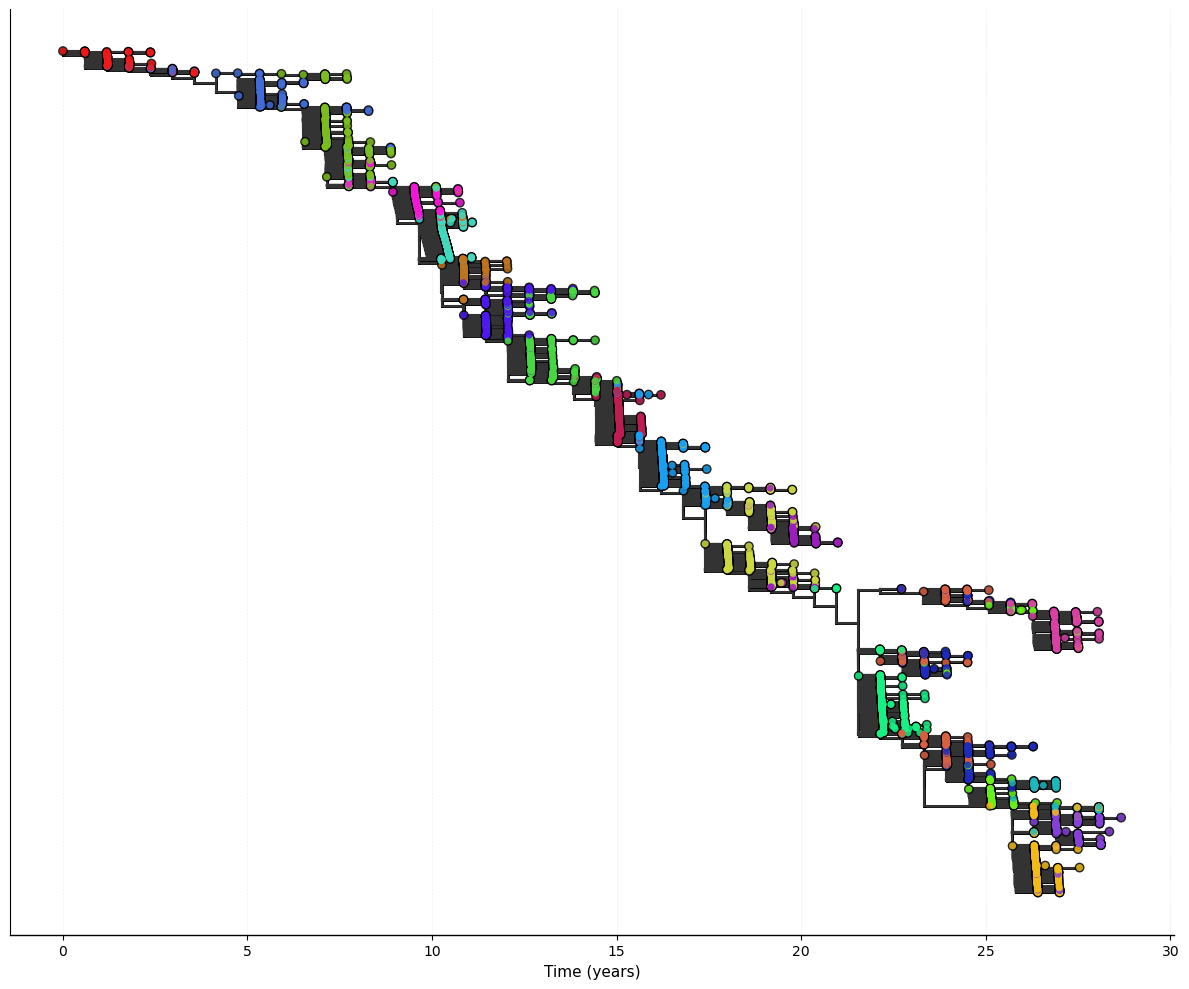

In [63]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot tree structure
tree.plotTree(ax, width=2)

# Plot tip points colored by variant
tree.plotPoints(
    ax, 
    target=lambda k: k.is_leaf(),
    size=lambda k: 25,
    colour=lambda k: k.traits.get('color', 'black'),
    alpha=0.85,
    zorder=100,
    linewidths=0.3  # Thin outline
)

# Make branches thinner and darker
tree.plotTree(ax, width=1.5, colour='#333333')

# Styling
ax.set_xlabel('Time (years)', fontsize=11)
ax.spines['bottom'].set_linewidth(1)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=10)

# Add clean grid
ax.grid(axis='x', alpha=0.2, linestyle='--', linewidth=0.5)

#plt.title('Phylogenetic Tree Colored by Variant', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

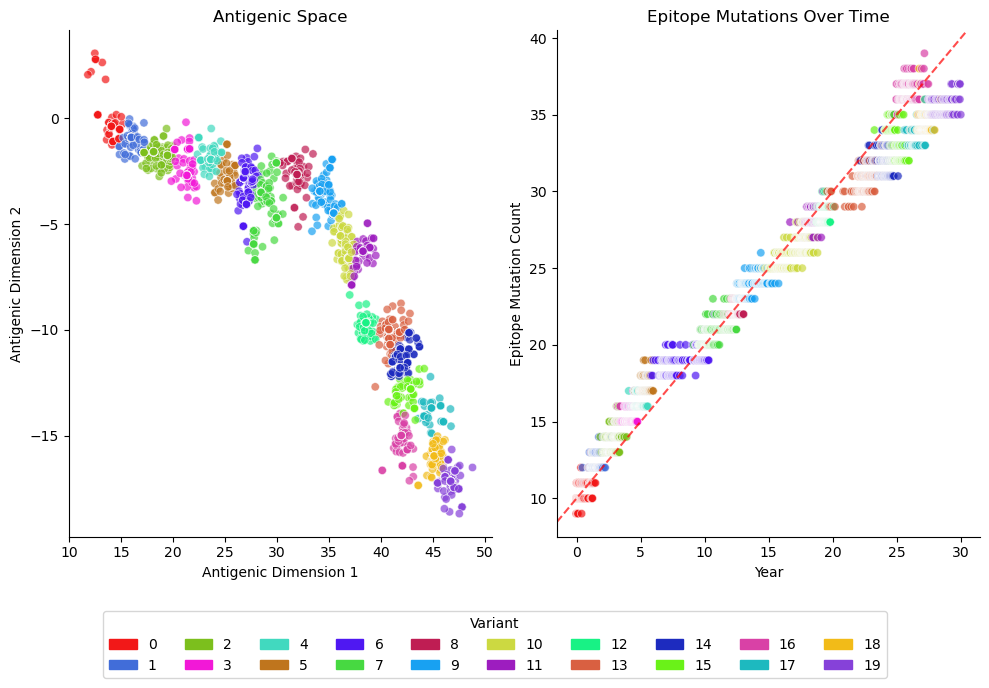

In [65]:
# Plot antigenic space and epitpoe mutations over time 

# 2x1 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Flatten axes for easy indexing
axes = axes.flatten()

# First subplot: Antigenic space colored by variant
sns.scatterplot(
    data=tips_df,
    x='ag1',
    y='ag2',
    hue='variant_ag',
    palette=variant_color_map,
    alpha=0.7,
    ax=axes[0],
    legend=False
)
axes[0].set_title('Antigenic Space')
axes[0].set_xlabel('Antigenic Dimension 1')
axes[0].set_ylabel('Antigenic Dimension 2')

# Second subplot: Number of epitope mutations over time
sns.scatterplot(
    data=tips_df,
    x='year',
    y='epitopeMutationCount',
    hue='variant_ag',
    palette=variant_color_map,
    alpha=0.7,
    ax=axes[1],
    legend=False
)
# Add y = 0.5x line
axes[1].axline((0, 10), slope=1.0, color='red', linestyle='--', alpha=0.7, label='1 epitope mutation per year')
axes[1].set_title('Epitope Mutations Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Epitope Mutation Count')


# Remove top and right spines for both plots
for ax in axes:
    sns.despine(ax=ax)

# Place a single legend under both of the plots but only the first 20 variants
handles = [
    mpatches.Patch(color=color, label=variant)
    for variant, color in list(variant_color_map.items())[:20]
]
fig.legend(title="Variant", handles=handles, loc='lower center', ncol=10, bbox_to_anchor=(0.5, -0.15))

# Tighten layout
plt.tight_layout()
plt.show()

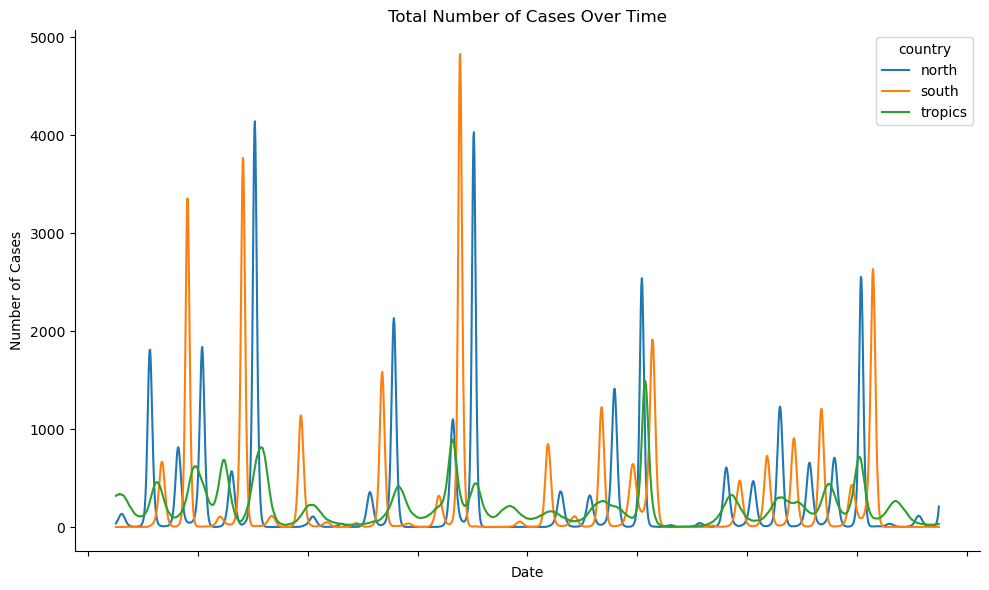

In [66]:
# Now plot the nnumber of cases over time as a density plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=cases_df,
    x='date',
    y='cases',
    hue='country',
    errorbar=None,
    color='blue'
)

# Remove x-axis tick labels for now
plt.gca().set_xticklabels([])
plt.title('Total Number of Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
sns.despine()
plt.tight_layout()
plt.show()

## Fourth Row: Observed Variant Frequencies

In [68]:
# Step 1: Calculate variant frequencies over time using seqs_df
# Aggregate across all demes for global view
freq_data = []
unique_dates = sorted(seqs_df['date'].unique())
unique_variants = sorted(seqs_df['variant'].unique())

for date_val in unique_dates:
    date_data = seqs_df[seqs_df['date'] == date_val]
    total_sequences = date_data['sequences'].sum()
    
    for variant in unique_variants:
        variant_data = date_data[date_data['variant'] == variant]
        variant_count = variant_data['sequences'].sum() if len(variant_data) > 0 else 0
        frequency = variant_count / total_sequences if total_sequences > 0 else 0
        
        freq_data.append({
            'date': date_val,
            'variant': variant,
            'frequency': frequency
        })

freq_df = pd.DataFrame(freq_data)
freq_df.head()

,date,variant,frequency
0,2024-12-22,0,1.0
1,2024-12-22,1,0.0
2,2024-12-22,2,0.0
3,2024-12-22,3,0.0
4,2024-12-22,4,0.0


In [ ]:
# Create clean stacked area plot like nextstrain
fig, ax = plt.subplots(figsize=(14, 6))

# Pivot data: rows=date, columns=variant, values=frequency
freq_pivot = freq_df.pivot(index='date', columns='variant', values='frequency').fillna(0)

# Resample to daily frequency and forward fill
freq_daily = freq_pivot.resample('D').ffill()

# Apply aggressive smoothing: 60-day rolling window
freq_smooth = freq_daily.rolling(window=60, center=True, min_periods=1).mean()

# Normalize to ensure frequencies sum to 1 at each timepoint
freq_smooth = freq_smooth.div(freq_smooth.sum(axis=1), axis=0)

# Convert dates to years (0-30 scale)
start_date = freq_smooth.index.min()
years = (freq_smooth.index - start_date).days / 365.25

# Reverse the order of variants for stacking (newest on top)
variants_reversed = list(reversed(freq_smooth.columns))

# Create stackplot with reversed order
ax.stackplot(
    years,
    *[freq_smooth[var].values for var in variants_reversed],
    colors=[variant_color_map.get(var, 'gray') for var in variants_reversed],
    alpha=0.9,
    linewidth=0
)

# Add variant labels in center of their range
# Calculate cumulative frequencies for label positioning (using reversed order)
freq_smooth_rev = freq_smooth[variants_reversed]
freq_cumsum = freq_smooth_rev.cumsum(axis=1)

for i, variant in enumerate(variants_reversed):
    # Find time range where variant freq > threshold
    variant_data = freq_smooth[variant]
    significant = variant_data > 0.05
    
    if significant.any():
        # Get first and last significant time
        sig_indices = variant_data[significant].index
        start_time = (sig_indices[0] - start_date).days / 365.25
        end_time = (sig_indices[-1] - start_date).days / 365.25
        mid_year = (start_time + end_time) / 2
        
        # Get y-position at midpoint
        mid_idx = sig_indices[len(sig_indices) // 2]
        if i == 0:
            y_bottom = 0
        else:
            y_bottom = freq_cumsum.loc[mid_idx, variant] - freq_smooth.loc[mid_idx, variant]
        y_middle = y_bottom + freq_smooth.loc[mid_idx, variant] / 2
        
        # Only label if peak frequency > 10%
        if variant_data.max() > 0.1:
            ax.text(
                mid_year, y_middle, str(variant),
                color='white', fontweight='bold', fontsize=10,
                ha='center', va='center',
                bbox=dict(facecolor='black', alpha=0.3, edgecolor='none', pad=2)
            )

# Styling
ax.set_xlim(0, 30)
ax.set_ylim(0, 1)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_xlabel('Time (years)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y*100)}%'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.show()

/var/folders/90/6t9_1yk52qd_sbpbmt4ym0540000gn/T/ipykernel_98600/378388783.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to ../../antigen-tex/figures/figure2_simulation_summary.pdf and ../../antigen-tex/figures/figure2_simulation_summary.png


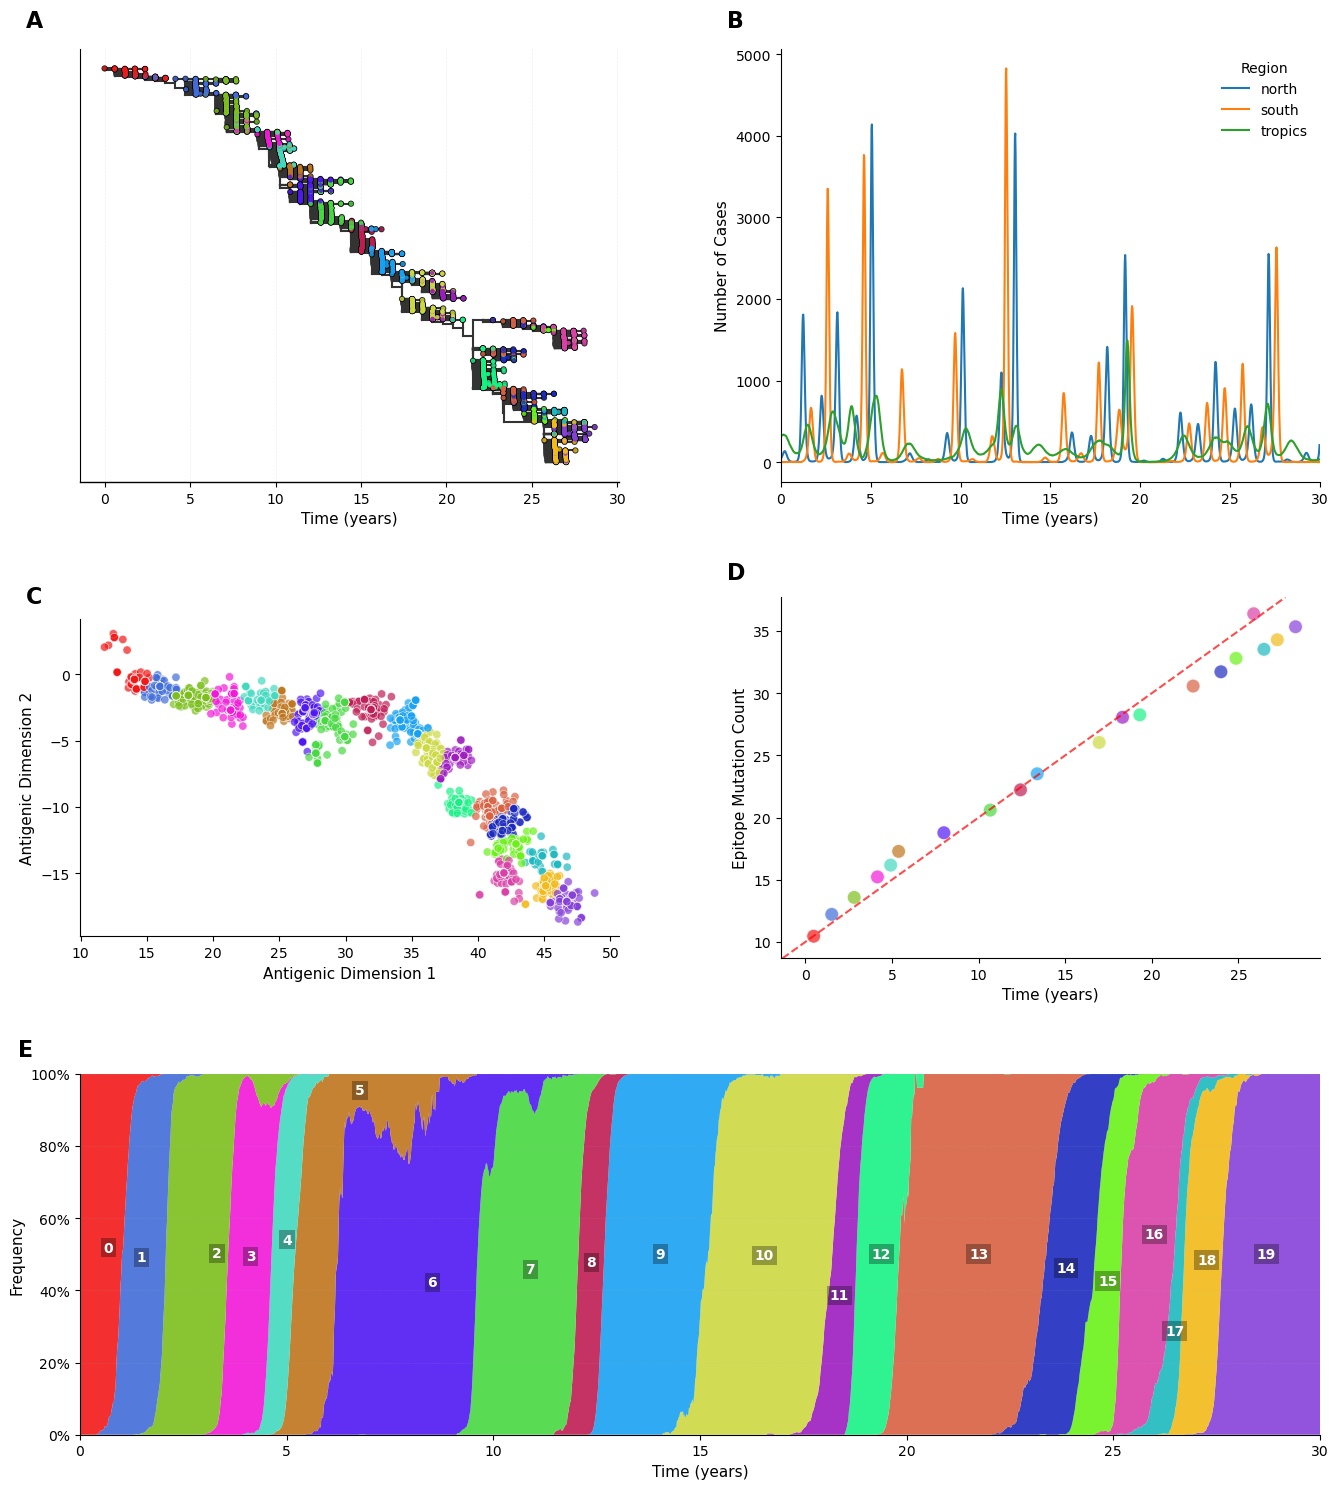

In [79]:
# Create combined figure with all 5 panels
fig = plt.figure(figsize=(16, 18))
gs = fig.add_gridspec(3, 2, height_ratios=[1.2, 1, 1], hspace=0.3, wspace=0.3)

# Row 1: Tree (left) and Case counts (right)
ax_tree = fig.add_subplot(gs[0, 0])
ax_cases = fig.add_subplot(gs[0, 1])

# Row 2: Antigenic space (left) and Epitope mutations (right)
ax_ag = fig.add_subplot(gs[1, 0])
ax_epi = fig.add_subplot(gs[1, 1])

# Row 3: Variant frequencies (spans both columns)
ax_freq = fig.add_subplot(gs[2, :])

# Panel A: Tree colored by variant
tree.plotTree(ax_tree, width=1.5, colour='#333333')
tree.plotPoints(
    ax_tree, 
    target=lambda k: k.is_leaf(),
    size=lambda k: 10,
    colour=lambda k: k.traits.get('color', 'black'),
    alpha=0.85,
    zorder=100,
    linewidths=0.3
)
ax_tree.set_xlabel('Time (years)', fontsize=11)
ax_tree.spines['bottom'].set_linewidth(1)
ax_tree.spines['right'].set_visible(False)
ax_tree.spines['top'].set_visible(False)
ax_tree.set_yticks([])
ax_tree.grid(axis='x', alpha=0.2, linestyle='--', linewidth=0.5)
ax_tree.text(-0.1, 1.05, 'A', transform=ax_tree.transAxes, fontsize=16, fontweight='bold')

# Panel B: Case counts over time
# Convert dates to years (0-30 scale) for cases
cases_start = cases_df['date'].min()
cases_years = (cases_df['date'] - cases_start).dt.days / 365.25
cases_plot = cases_df.copy()
cases_plot['years'] = cases_years

sns.lineplot(
    data=cases_plot,
    x='years',
    y='cases',
    hue='country',
    errorbar=None,
    ax=ax_cases
)
ax_cases.set_xlim(0, 30)
ax_cases.set_xlabel('Time (years)', fontsize=11)
ax_cases.set_ylabel('Number of Cases', fontsize=11)
ax_cases.spines['top'].set_visible(False)
ax_cases.spines['right'].set_visible(False)
ax_cases.legend(title='Region', frameon=False)
ax_cases.text(-0.1, 1.05, 'B', transform=ax_cases.transAxes, fontsize=16, fontweight='bold')

# Panel C: Antigenic space
sns.scatterplot(
    data=tips_df,
    x='ag1',
    y='ag2',
    hue='variant_ag',
    palette=variant_color_map,
    alpha=0.7,
    ax=ax_ag,
    legend=False
)
ax_ag.set_aspect('equal')
ax_ag.set_xlabel('Antigenic Dimension 1', fontsize=11)
ax_ag.set_ylabel('Antigenic Dimension 2', fontsize=11)
ax_ag.spines['top'].set_visible(False)
ax_ag.spines['right'].set_visible(False)
ax_ag.text(-0.1, 1.05, 'C', transform=ax_ag.transAxes, fontsize=16, fontweight='bold')

# Panel D: Epitope mutations over time (mean per variant)
# Calculate mean epitope mutation count and year for each variant
variant_summary = tips_df.groupby('variant_ag').agg({
    'year': 'mean',
    'epitopeMutationCount': 'mean'
}).reset_index()

sns.scatterplot(
    data=variant_summary,
    x='year',
    y='epitopeMutationCount',
    hue='variant_ag',
    palette=variant_color_map,
    s=100,
    alpha=0.7,
    ax=ax_epi,
    legend=False
)
ax_epi.axline((0, 10), slope=1.0, color='red', linestyle='--', alpha=0.7, label='1 epitope mutation per year')
ax_epi.set_xlabel('Time (years)', fontsize=11)
ax_epi.set_ylabel('Epitope Mutation Count', fontsize=11)
ax_epi.spines['top'].set_visible(False)
ax_epi.spines['right'].set_visible(False)
ax_epi.text(-0.1, 1.05, 'D', transform=ax_epi.transAxes, fontsize=16, fontweight='bold')

# Panel E: Variant frequencies (use existing smoothed data)
# Reverse the order of variants for stacking (newest on top)
variants_reversed = list(reversed(freq_smooth.columns))

ax_freq.stackplot(
    years,
    *[freq_smooth[var].values for var in variants_reversed],
    colors=[variant_color_map.get(var, 'gray') for var in variants_reversed],
    alpha=0.9,
    linewidth=0
)

# Add variant labels
# Calculate cumulative frequencies for label positioning (using reversed order)
freq_smooth_rev = freq_smooth[variants_reversed]
freq_cumsum = freq_smooth_rev.cumsum(axis=1)

for i, variant in enumerate(variants_reversed):
    variant_data = freq_smooth[variant]
    significant = variant_data > 0.05
    
    if significant.any():
        sig_indices = variant_data[significant].index
        start_time = (sig_indices[0] - start_date).days / 365.25
        end_time = (sig_indices[-1] - start_date).days / 365.25
        mid_year = (start_time + end_time) / 2
        
        mid_idx = sig_indices[len(sig_indices) // 2]
        if i == 0:
            y_bottom = 0
        else:
            y_bottom = freq_cumsum.loc[mid_idx, variant] - freq_smooth.loc[mid_idx, variant]
        y_middle = y_bottom + freq_smooth.loc[mid_idx, variant] / 2
        
        if variant_data.max() > 0.1:
            ax_freq.text(
                mid_year, y_middle, str(variant),
                color='white', fontweight='bold', fontsize=10,
                ha='center', va='center',
                bbox=dict(facecolor='black', alpha=0.3, edgecolor='none', pad=2)
            )

ax_freq.set_xlim(0, 30)
ax_freq.set_ylim(0, 1)
ax_freq.set_ylabel('Frequency', fontsize=11)
ax_freq.set_xlabel('Time (years)', fontsize=11)
ax_freq.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y*100)}%'))
ax_freq.spines['top'].set_visible(False)
ax_freq.spines['right'].set_visible(False)
ax_freq.grid(axis='y', alpha=0.3, linestyle=':', linewidth=0.5)
ax_freq.text(-0.05, 1.05, 'E', transform=ax_freq.transAxes, fontsize=16, fontweight='bold')

plt.tight_layout()

# Save figure
save_path = '../../antigen-tex/figures/figure2_simulation_summary'
plt.savefig(f'{save_path}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{save_path}.png', dpi=300, bbox_inches='tight')
print(f"Figure saved to {save_path}.pdf and {save_path}.png")

plt.show()